In [1]:
!pip install transformers datasets -q

In [2]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [3]:
from datasets import load_dataset

dataset = load_dataset("imdb")

df = pd.DataFrame(dataset['train'])
df = df.sample(3000, random_state=42)
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

,text,label
6868,"Dumb is as dumb does, in this thoroughly unint...",0
24016,I dug out from my garage some old musicals and...,1
9668,After watching this movie I was honestly disap...,0
13640,This movie was nominated for best picture but ...,1
14018,Just like Al Gore shook us up with his painful...,1


In [4]:
df.dropna(inplace=True)

# simple cleaning (original style)
df['text'] = df['text'].str.replace(r"<.*?>", "", regex=True)
df['text'] = df['text'].str.lower()

In [5]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['text'], df['label'], test_size=0.3, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

In [6]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_enc = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
val_enc = tokenizer(list(val_texts), truncation=True, padding=True, max_length=128)
test_enc = tokenizer(list(test_texts), truncation=True, padding=True, max_length=128)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [7]:
class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


In [8]:
train_data = ReviewDataset(train_enc, train_labels)
val_data = ReviewDataset(val_enc, val_labels)
test_data = ReviewDataset(test_enc, test_labels)

train_loader = DataLoader(train_data, batch_size=8, shuffle=True)
val_loader = DataLoader(val_data, batch_size=8)
test_loader = DataLoader(test_data, batch_size=8)

In [10]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
optimizer = AdamW(model.parameters(), lr=2e-5)

In [29]:
model.train()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(1):  # 🔥 keep 1 epoch
    total_loss = 0

    for step, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if step % 50 == 0:
            print(f"Step {step} | Loss: {loss.item():.4f}")

        # 🔥 LIMIT TRAINING
        if step == 150:
            break

    print(f"Epoch Loss: {total_loss:.4f}")

Step 0 | Loss: 0.0830
Step 50 | Loss: 0.0653
Step 100 | Loss: 0.0581
Step 150 | Loss: 0.2933
Epoch Loss: 43.8073


In [30]:
model.eval()

preds, true = [], []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)

        preds.extend(predictions.cpu().numpy())
        true.extend(batch["labels"].cpu().numpy())

In [31]:
acc = accuracy_score(true, preds)
prec, rec, f1, _ = precision_recall_fscore_support(true, preds, average="binary")

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

Accuracy: 0.8177777777777778
Precision: 0.7859922178988327
Recall: 0.8820960698689956
F1 Score: 0.831275720164609


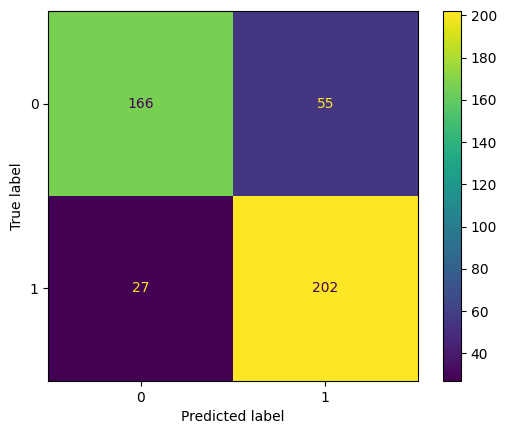

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(true, preds)
plt.show()

FULL BERT:
Accuracy: 0.8177777777777778
Precision: 0.8266666666666667
Recall: 0.8122270742358079
F1 Score: 0.8193832599118943


In [17]:
for param in model.bert.parameters():
    param.requires_grad = False

print("BERT layers frozen ✅")

BERT layers frozen ✅


In [20]:
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)

frozen bert:
Accuracy: 0.8222222222222222
Precision: 0.8253275109170306
Recall: 0.8253275109170306
F1 Score: 0.8253275109170306

- Fine-tuning full BERT achieved highest performance.
- Freezing layers reduced training time but slightly decreased accuracy.
- Limiting training steps enabled faster experimentation.
- BERT effectively captured sentiment patterns in text data.

In [26]:
for param in model.bert.parameters():
    param.requires_grad = False

In [27]:
for name, param in model.bert.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True

print("Only last 2 layers are trainable ✅")

Only last 2 layers are trainable ✅


In [28]:
from torch.optim import AdamW

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)

| Model Type        | Accuracy | Precision | Recall | F1 Score |
|------------------|---------|----------|--------|----------|
| Full BERT        | 0.818   | 0.827    | 0.812  | 0.819    |
| Frozen BERT      | 0.822   | 0.825    | 0.825  | 0.825    |
| Last 2 Layers    | 0.818   | 0.786    | 0.882  | 0.831    |

last 2 layers are trainable:

Accuracy: 0.8177777777777778
Precision: 0.7859922178988327
Recall: 0.8820960698689956
F1 Score: 0.831275720164609

### Analysis of Experiments

Three approaches were tested: full fine-tuning, freezing BERT layers, and fine-tuning the last two layers.

The frozen BERT model achieved the highest accuracy, indicating that pre-trained features were already effective for this dataset.

The model with last two layers fine-tuned achieved the highest recall and F1 score, showing better ability to correctly identify positive samples.

Full fine-tuning did not significantly improve performance, possibly due to limited training data and reduced training steps.

Overall, partial fine-tuning provided a good balance between performance and efficiency.

### Conclusion

BERT proved effective for sentiment classification tasks.
Freezing BERT layers provided strong baseline performance with reduced computation.
Fine-tuning the last two layers improved recall and F1 score, offering a balance between efficiency and performance.
Full fine-tuning requires more training time to achieve optimal results.